# Feedback from previous weeks and other and hints

1. Be careful about your environment remembering variables. Make sure your code works in a new _clean_ environment. In Colab: `Runtime`->`restart Runtime`, in Anaconda's Jupyter: `Kernel`->`Restart`.
2. Keep the file names when saving to GitHub. It's always possible to go back to a previous version, you are not losing anything.
3. Run all the cells before saving to GitHub so the output is saved.
4. Graphs without labels (or units when appropriate) are not worth any point.
5. Do put in sufficient explanatory comments in your code.

For this week you can use these imports at the start of your programs:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Introduction

In this worksheet we examine how to solve Ordinary Differential Equations (ODEs) using Python. ODEs are of course central to the study of physics as nearly all our descriptions of nature are formulated, and solved, using ODEs of some sort.

In PX1224 you studied how to solve differential equations using the simple Euler method and the Euler-Cromer method. Revise week 9 and 10 from last year and re-run your code to make sure you understand it. This week introduces you to a powerful method to solve ODEs which is faster and more robust than Euler or Euler-Cromer methods, and is capable of handling more complicated differential equations.

## The scipy library and odeint

The `scipy` library for Python includes many functions for scientific computing and data analysis. The function `odeint` will let us solve numerically one or more _first order_ ODEs using various sophisticated algorithms. It is used to find a solution $y(t)$ to a differential equation:

```python
y = scipy.integrate.odeint(func, y0, t)
```

where `t` is the sequence of time points for which to solve for $y(t)$, and `y` is the returned solution array of the same length. `y0` is the initial value of `y`, and `func` is the name of a function which defines the derivative of `y`.

The full description is available in the online [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html), but let's start with a simple example. Take the ODE:

$$
\frac{dy}{dt} = - \lambda y
$$

which has the analytic solution $y = y_0 \exp(−\lambda t)$ as verified by substitution. It describes radioactive decay for example, where $y(t)$ represents the number of undecayed nuclei at a time t.

Let's first set things up, with, say, $y_0=1000$:

In [2]:
npts = 1000 # Number of points
tmax = 10 # Maximum time

# setting up the time array:
t = np.linspace(0.0, tmax, npts)

# And the initial conditions:
t[0] = 0.0
y0 = 1e3

So, in this case using the `odeint()` function would look like this:

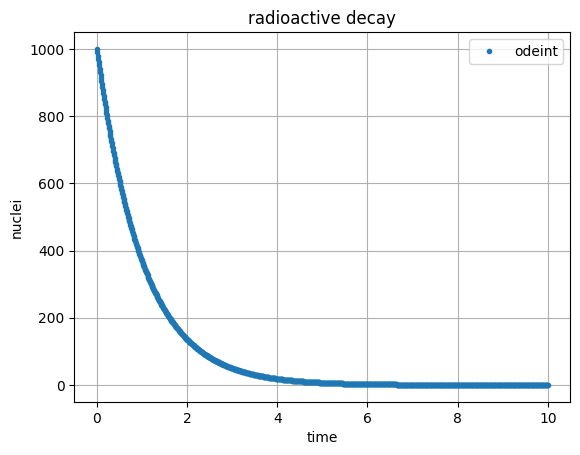

In [3]:
lam = 1.0
def f(y, t): # return derivative(s) of the array y
    return -lam*y

y_odeint = odeint(f, y0, t)

plt.plot(t, y_odeint,'.',label='odeint')
plt.xlabel('time')
plt.ylabel('nuclei')
plt.title('radioactive decay')
plt.legend()
plt.grid()

Let's compare this solution obtained with `odeint()` with the analytical solution:

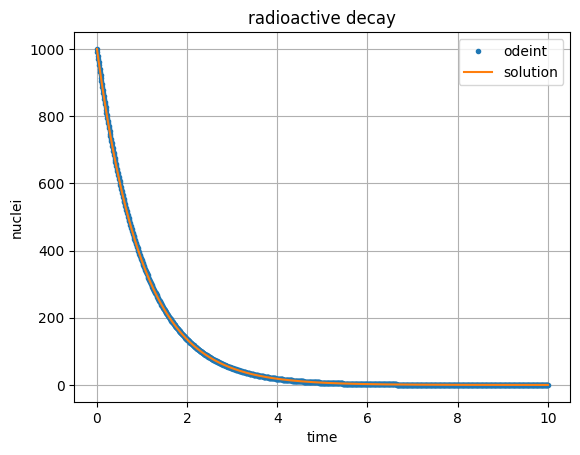

In [4]:
def solution(t): # return the analytic solution
    return y0*np.exp(-lam*t)

plt.plot(t, y_odeint,'.',label='odeint')
plt.plot(t, solution(t),label='solution')
plt.xlabel('time')
plt.ylabel('nuclei')
plt.title('radioactive decay')
plt.legend()
plt.grid()

We can also compare this methods to the Euler method that you used last year:

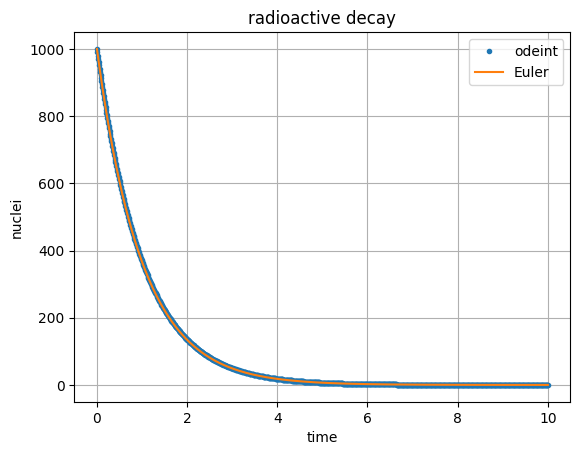

In [5]:
# use Euler's method to integrate equation for radioactive decay
# y_euler is the array for the solution y:
y_euler = np.zeros_like(t)
y_euler[0] = y0

dt = tmax/npts
for i in range(npts -1):
    y_euler[i+1] = y_euler[i] - lam*y_euler[i]*dt

plt.plot(t, y_odeint,'.',label='odeint')
plt.plot(t, y_euler, label='Euler')
plt.xlabel('time')
plt.ylabel('nuclei')
plt.title('radioactive decay')
plt.legend()
plt.grid()

## Improving the function definition

In order to be able to use a different value of $\lambda$ without modifying the function itself each time (that would be a very bad idea) you should modify the function definition and the way it is called like this:

In [6]:
npts = 1000 # Number of points
tmax = 10 # Maximum time

# setting up the time array:
t = np.linspace(0.0, tmax, npts)

def f(y, t, lam): # return derivative(s) of the array y
    return -lam*y

yinit = 1e3 # initial value
y_odeint = odeint(f, yinit, t, args=(2.0,))

The extra argument to the function needs to be passed to odeint as a “tuple” of values, i.e. a series of values in brackets separated by commas. So $\lambda$ is equal to 2.0 in this example.

## Solving several ODEs at once

The real power of `odeint` lies in the fact that it can solve several ODEs all at once, which can be coupled equations. Since we can transform a second order ODE into two coupled first order ODEs, you can immediately see why this is so useful.

Take the example of the ODE describing the displacement $y$ of a mass on a spring:

$$
m\frac{d^2y}{dt^2} = -ky
$$

Defining $y' = dy/dt$ (which is the velocity of the mass) we can re-write this second order ODE as the two first order ODEs:

$$
\begin{aligned}
\frac{dy}{dt} &= y' \\
\frac{dy'}{dt} &= -\frac{k}{m}y
\end{aligned}
$$

In order to work with these two derivatives, `odeint` needs them as elements of an array, so that `y` is a 2D array:

$$
\begin{aligned}
\frac{dy[0]}{dt} &= y[1] \\
\frac{dy[1]}{dt} &= -\frac{k}{m}y[0]
\end{aligned}
$$

$y[0]$ contains all the "zeroth" derivative as a function of time, and $y[1]$ the first derivatives. We modify the code defining the function and the way that `odeint` is used accordingly:

In [7]:
def f(y, t): # return derivatives of the array y
    k = 10.0
    m = 1.0
    return [ y[1], # the first equation dy[0]/dt
            -(k/m)*y[0] # the second equation dy[1]/dt
           ]

yinit = [0.1, 0] # TWO initial values, y and y'
y = odeint(f, yinit , t)

And y is indeed a 2D array, with the zeroth derivatives in the first column, and the first derivatives in the second column:

In [8]:
print(y)

[[ 0.1         0.        ]
 [ 0.0999499  -0.01000832]
 [ 0.09979967 -0.02000663]
 ...
 [ 0.09897162 -0.0452358 ]
 [ 0.09846931 -0.05511855]
 [ 0.09786833 -0.06494608]]


# Exercises


This must be marked before you leave the lab. Mark weighting is in brackets. **Save your work to GitHub after having run all cells with `Runtime` -> `Restart and run all`. And do not change the notebook's filename.**. Do add comments to your code, you'll lose points if your code is hard to understand. Graphs without labels (or units when appropriate) are not worth any point.

## Exercise 0

[0] Using the radioactive decay differential equation from the start of the worksheet, measure with `curve_fit()` the decay constant $\lambda$ from the (noisy) measurements of Oxygen-22 nuclei as a function of time from the file [ex0.txt](https://raw.githubusercontent.com/PX2134/data/master/week8/ex0.txt). The starting number of nuclei was `y0=100`.

(this exercise is for demonstration purposes and won't be marked)

**Note**: this is similar to question 4 of exercise 2...


In [9]:
def f(y,t, lam):
  return -lam*y

In [10]:
def func(t,lam):
  yinit=100
  y_odeint=odeint(f,yinit, t, args=(lam,))
  return y_odeint[:,0]

/tmp/ipython-input-296183445.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


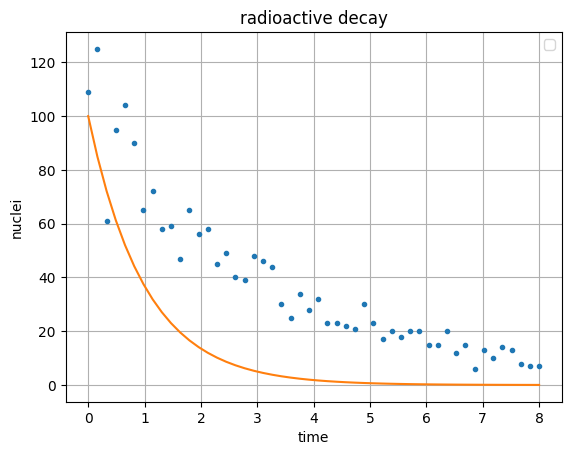

In [11]:
data=np.loadtxt('https://raw.githubusercontent.com/PX2134/data/master/week8/ex0.txt')

time=data[:,0]
y_data=data[:,1]

plt.plot(time,y_data, '.')
plt.plot(time,func(time,1.0))
plt.xlabel('time')
plt.ylabel('nuclei')
plt.title('radioactive decay')
plt.legend()
plt.grid()

In [12]:
from scipy.optimize import curve_fit

In [13]:
popt,pcov = curve_fit(func,time,y_data)

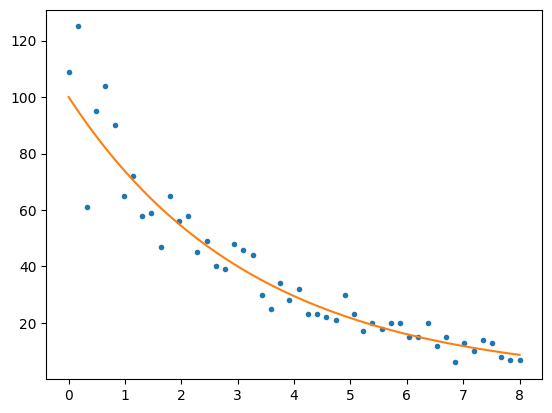

In [14]:
plt.plot(time,y_data,'.')
plt.plot(time,func(time,popt[0]))


## Exercise 1

 (1). [2] Using the last Python snippet as a guide, solve the ODE for a mass on a spring and plot the result for a suitable range of time.

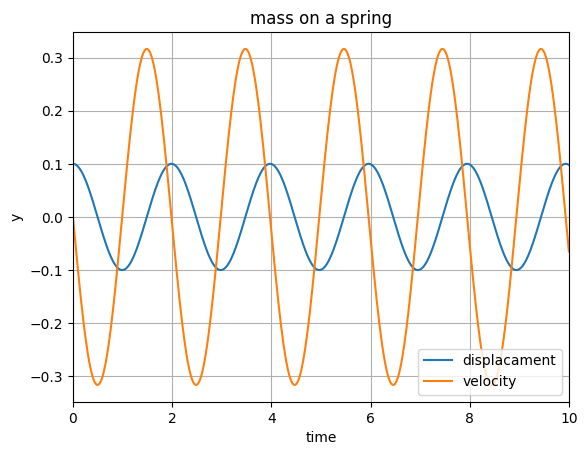

In [15]:
def f(y, t): # return derivatives of the array y
    k = 10.0
    m = 1.0
    return [ y[1], # the first equation dy[0]/dt
            -(k/m)*y[0] # the second equation dy[1]/dt
           ]

yinit = [0.1, 0] # TWO initial values, y and y'
y = odeint(f, yinit , t)

plt.plot(t,y[:,0], label='displacament')
plt.plot(t,y[:,1], label='velocity')
plt.xlim(0,10)
plt.grid()
plt.xlabel('time')
plt.ylabel('y')
plt.title('mass on a spring')
plt.legend()


 (2). [3] Modify your code so that the derivatives function accepts the parameters $k$ and $m$ instead of defining them within the function. Plot the results.

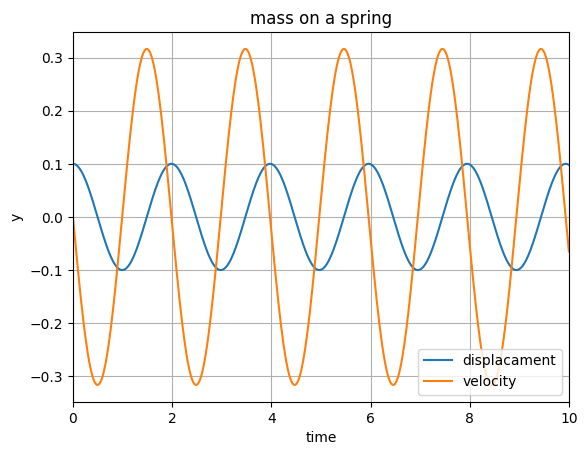

In [16]:
def f(y, t, k, m):
  yinit = [0.1, 0] # TWO initial values, y and y'
  y = odeint(f, yinit , t)
  return [y[1], -(k/m)*y[0]]

plt.plot(t,y[:,0], label='displacament')
plt.plot(t,y[:,1], label='velocity')
plt.xlim(0,10)
plt.grid()
plt.xlabel('time')
plt.ylabel('y')
plt.title('mass on a spring')
plt.legend()

 (3). [3] Finally, modify your code, with the above improvements to the function, to solve for the damped mass on a spring:

$$
\begin{aligned}
\frac{dy}{dt} &= y' \\
\frac{dy'}{dt} &= -\frac{k}{m}y -\frac{b}{m}\frac{dy}{dt}
\end{aligned}
$$

Modify your derivatives function to accept the damping parameter $b$ in addition to the parameter $k$ and $m$. Plot the results for $b=0.5$.


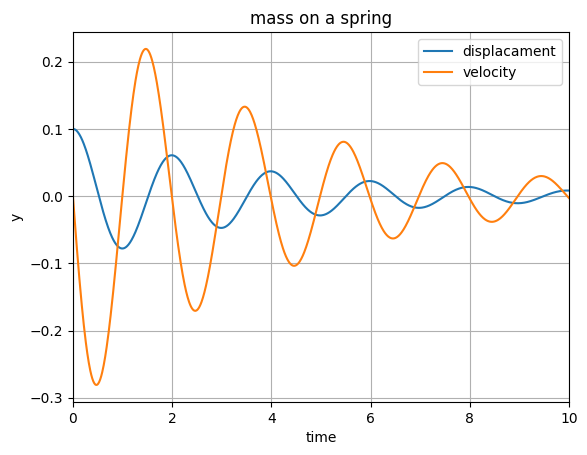

In [17]:
def f(y, t, k, m, b):
  return [y[1], -(k/m)*y[0] -(b/m)*y[1]]

k=10
m=1
b=0.5
yinit = [0.1, 0] # TWO initial values, y and y'
y = odeint(f, yinit , t, args=(k,m,b))



plt.plot(t,y[:,0], label='displacament')
plt.plot(t,y[:,1], label='velocity')
plt.xlim(0,10)
plt.grid()
plt.xlabel('time')
plt.ylabel('y')
plt.title('mass on a spring')
plt.legend()

(4). [5] For the next question, you are trying to measure the spring constant $k$ and the damping parameter $b$ of a spring. You attach a known mass $m$ of 1.0 kg to the spring, move it `y0=0.5` meters from rest, release it at zero speed, and use a detector to measure its displacement as a function of time. Unfortunately this is a measurement done inside a nuclear reactor and there's a lot of noise on the detector... Your measurement is saved in the file [spring_measurement.txt](https://raw.githubusercontent.com/PX2134/data/master/week8/spring_measurement.txt).

- plot this file, the position of the mass at the end of the spring as a function of time

We will use `curve_fit()` to fit this data, the documentation is [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html). As a quick summary: `curve_fit()` takes 3 mandatory arguments (the function to fit `func`, the data `x_data` to apply this function to, and the data `y_data` the fitting function will be tweaked to fit), e.g.:
```python
popt,pcov = curve_fit(func,x_data,y_data)
```
The return values are the list of best fit values `popt` and the corresponding covariance matrix `pcov`. The fitting function `func()` **must** have a specific signature: it must take the independent variable as the first argument and the parameters to fit as separate remaining arguments. For instance, it must be possible to have:
```python
y_predicted = func(x_data,some,guess,parameters)
```
And in that case, `y_predicted` would be compared to `y_data` by `curve_fit` to assess wether `[some,guess,parameters]` is a good fit for `y_data`.
`curve_fit` also accepts optional parameters, such as an initial guess `p0` (a list of parameters) for the initial fit parameters. You should always try to plot `y_initial_guess=func(x_data,*p0)`, the prediction of `func` with the inital guess, agains the data `y_data`.

- define a function which takes as input an array of time, and two parameters $k$ and $b$. It should call `odeint()` to solve the damped spring ODE with a fixed mass of 1kg, and return the array of positions corresponding to the array of time for that spring. You will need to define in the function the initial position, initial speed, and the mass. Use the function you defined above.

- call that function with some initial guess $k$ and $b$, and plot that prediction agains the data from `spring_measurement.txt`

- run `curve_fit` with the function you created and give your estimates for the spring constant and damping parameter of the spring. Make a plot if you want to check your answer.

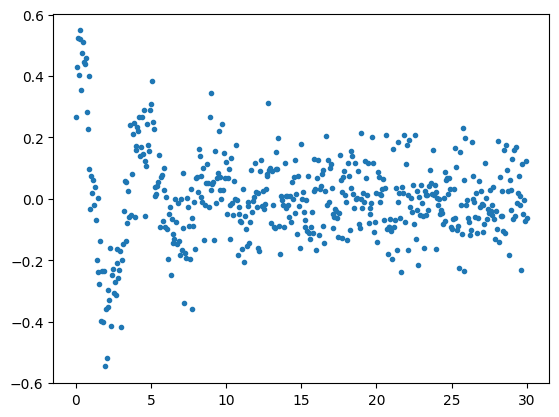

Optimized spring constant (k): 9.7303
Optimized damping parameter (b): 0.5189


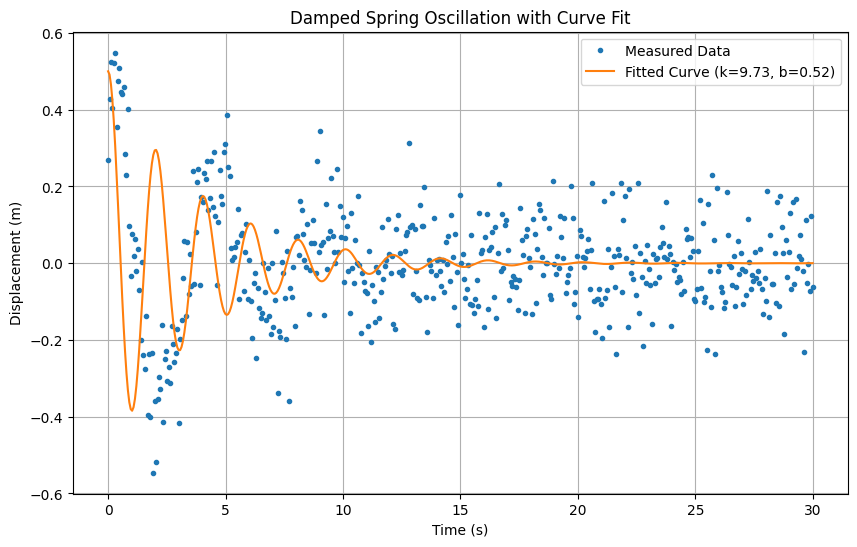

In [18]:
data=np.loadtxt('https://raw.githubusercontent.com/PX2134/data/master/week8/spring_measurement.txt')

x_data=data[:,0]
y_data=data[:,1]
plt.plot(x_data,y_data,'.')
plt.show()

def f(y, t, k, m, b):
  return [y[1], -(k/m)*y[0] -(b/m)*y[1]]

k=10
m=1
b=0.5
yinit = [0.5, 0] # TWO initial values, y and y'

def damped_spring_model(t,k,b):
  y = odeint(f, yinit , t, args=(k,m,b))
  return y[:,0]


'''
initial guess for k and b
'''
guess=[10,0.5]

popt, pcov = curve_fit(damped_spring_model, x_data, y_data, p0=guess)

k_optimized = popt[0]
b_optimized = popt[1]

print(f"Optimized spring constant (k): {k_optimized:.4f}")
print(f"Optimized damping parameter (b): {b_optimized:.4f}")

y_fitted = damped_spring_model(x_data, k_optimized, b_optimized)

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, '.', label='Measured Data')
plt.plot(x_data, y_fitted, '-', label=f'Fitted Curve (k={k_optimized:.2f}, b={b_optimized:.2f})')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Damped Spring Oscillation with Curve Fit')
plt.legend()
plt.grid(True)
plt.show()


## Exercise 2

[7] The driven van der Pol oscillator obeys the ODE:

$$
\frac{d^2y}{dt^2} - m(1 - y^2) \frac{dy}{dt} + y - A \sin(\omega t) = 0
$$

It is an example of a non-linear oscillator and can show mathematically chaotic behaviour.

Write the equation as two coupled first order ODEs and calculate its behaviour.

Plot graphs of $y$ versus $t$ and $y'$ versus $y$. The latter plot is called a "phase space plot" or "phase portrait".
(**Hint**: pick starting parameter values of $m = 8$, $A = 1$ and $\omega = 0.6$ and vary them to get interesting plots. You will need to pick a suitable range of time.)

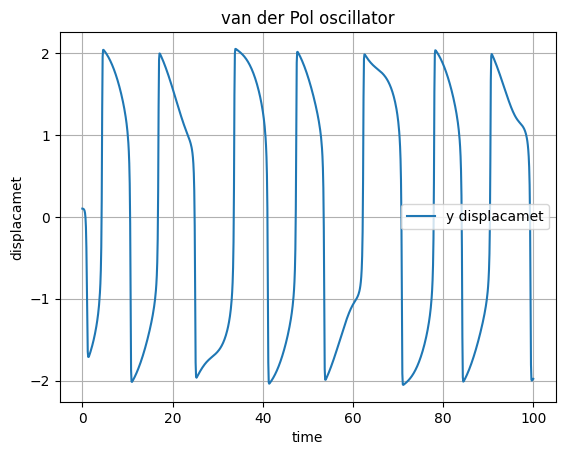

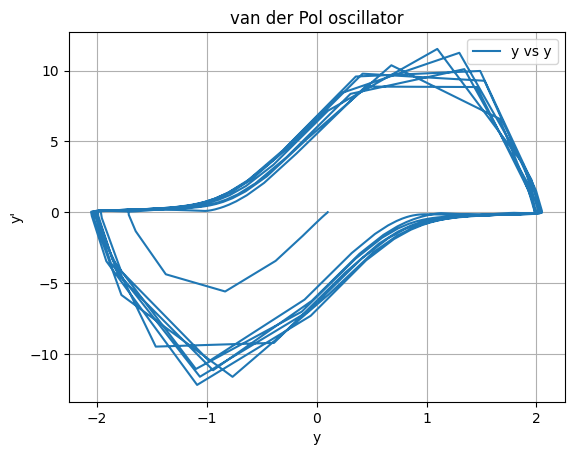

In [20]:
from scipy.integrate._ivp.ivp import solve_event_equation

def van_der_pol_deriv(y_vec, t, mu, A, omega):
  dydt=y_vec[1]
  d2ydy2=mu*(1-y_vec[0]**2) * y_vec[1] - y_vec[0] + A*np.sin(omega*t)
  return [dydt, d2ydy2]

mu=8
A=1
omega=0.6

yinit=[0.1,0]

'''time array'''
t_max = 100
npts=1000
t_vdP = np.linspace(0 , t_max, npts)

solve_vdp=odeint(van_der_pol_deriv, yinit, t_vdP, args=(mu,A,omega))

plt.plot(t_vdP, solve_vdp[:,0], label='y displacamet')
plt.xlabel('time')
plt.ylabel('displacamet')
plt.title('van der Pol oscillator')
plt.legend()
plt.grid()
plt.show()

plt.plot(solve_vdp[:,0], solve_vdp[:,1], label='y vs y')
plt.xlabel('y')
plt.ylabel('y\'')
plt.title('van der Pol oscillator')
plt.legend()
plt.grid()
plt.show()

In [26]:
HERE

NameError: name 'HERE' is not defined

## Comprehensive Review of ODEs and `odeint` in this Exercise Sheet

This section summarizes the key concepts, functions, and code shortcuts demonstrated in this worksheet, which are crucial for understanding and solving Ordinary Differential Equations (ODEs) using Python's `scipy.integrate.odeint`.

### 1. Introduction to Solving First-Order ODEs with `odeint`

`odeint` is a powerful function from the `scipy.integrate` library used to numerically solve systems of first-order ODEs. It takes three main arguments:

*   `func`: A function that defines the derivatives of the system. It *must* take `y` (the dependent variable(s)) and `t` (the independent variable, usually time) as its first two arguments.
*   `y0`: The initial condition(s) for `y`.
*   `t`: A sequence of time points for which to solve for `y(t)`.

**Example: Radioactive Decay**
The basic structure for a single first-order ODE like $dy/dt = -\lambda y$ (radioactive decay) is shown below.


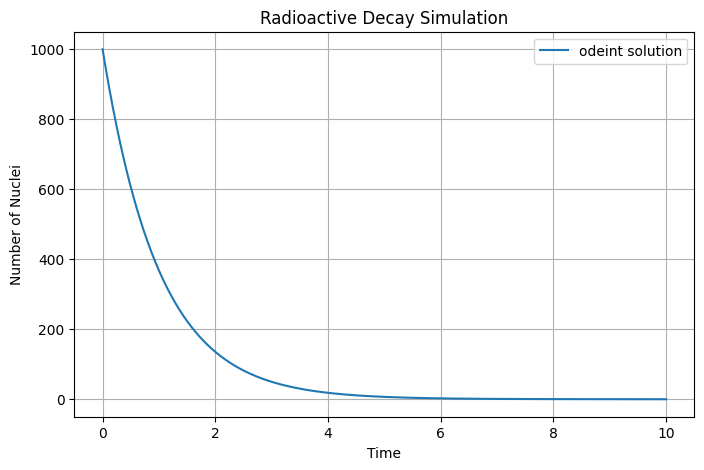

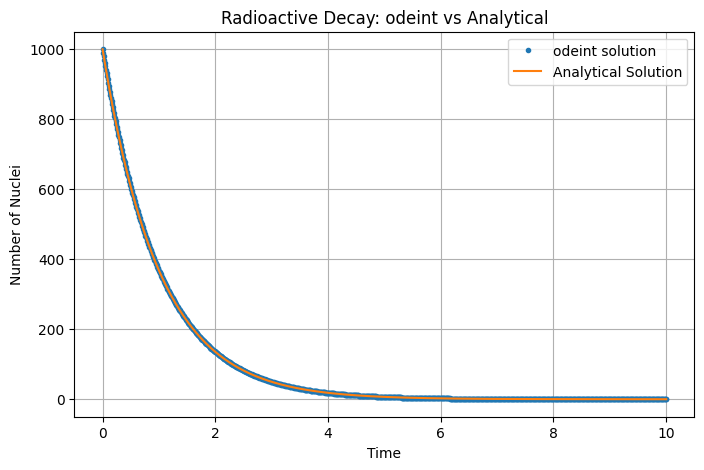

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Define the derivative function
def radioactive_decay_func(y, t, lam):
    return -lam * y

# 2. Set up initial conditions and time array
npts = 1000  # Number of points
tmax = 10    # Maximum time
t_decay = np.linspace(0.0, tmax, npts)
y0_decay = 1000 # Initial number of nuclei
lambda_val = 1.0 # Decay constant

# 3. Solve the ODE using odeint
y_odeint_decay = odeint(radioactive_decay_func, y0_decay, t_decay, args=(lambda_val,))

# 4. Plotting the result
plt.figure(figsize=(8, 5))
plt.plot(t_decay, y_odeint_decay, label='odeint solution')
plt.xlabel('Time')
plt.ylabel('Number of Nuclei')
plt.title('Radioactive Decay Simulation')
plt.legend()
plt.grid(True)
plt.show()

# Analytical solution for comparison
def analytic_solution_decay(t, y0, lam):
    return y0 * np.exp(-lam * t)

plt.figure(figsize=(8, 5))
plt.plot(t_decay, y_odeint_decay, '.', label='odeint solution')
plt.plot(t_decay, analytic_solution_decay(t_decay, y0_decay, lambda_val), label='Analytical Solution')
plt.xlabel('Time')
plt.ylabel('Number of Nuclei')
plt.title('Radioactive Decay: odeint vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

### 2. Passing Additional Parameters to the Derivative Function

If your derivative function requires parameters (like $\lambda$ in the decay example, or $k, m, b$ in the spring examples) that are not `y` or `t`, you can pass them using the `args` argument in `odeint`. This `args` argument must be a tuple.

**Code Shortcut:** When defining `odeint`, use `args=(param1, param2, ...)`. The derivative function `func` must also accept these parameters in the same order after `y` and `t`.


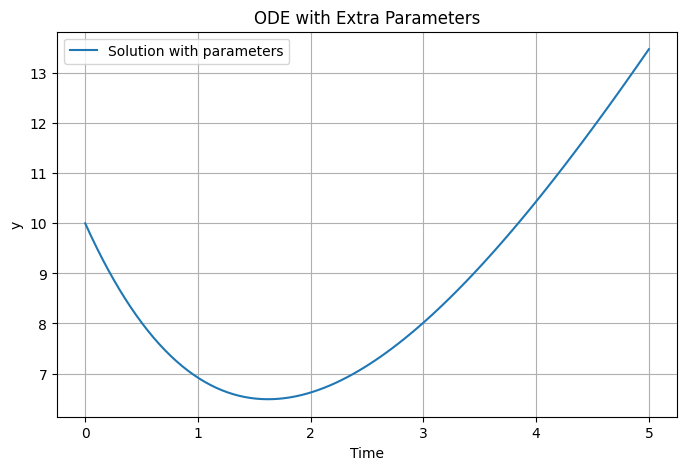

In [22]:
# Example of passing parameters (already shown in radioactive decay above, but explicitly here)

def derivative_with_params(y, t, alpha, beta):
    return -alpha * y + beta * t

initial_y = 10
t_range = np.linspace(0, 5, 100)

# Pass alpha=0.5, beta=2.0
solution_with_params = odeint(derivative_with_params, initial_y, t_range, args=(0.5, 2.0))

plt.figure(figsize=(8, 5))
plt.plot(t_range, solution_with_params, label='Solution with parameters')
plt.xlabel('Time')
plt.ylabel('y')
plt.title('ODE with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

### 3. Solving Coupled First-Order ODEs (Higher-Order ODEs)

`odeint` can solve systems of coupled first-order ODEs. To solve a higher-order ODE (e.g., a second-order ODE), you first need to convert it into a system of first-order ODEs.

**Transformation Shortcut:**
For a second-order ODE like $m\frac{d^2y}{dt^2} = F(y, \frac{dy}{dt}, t)$:
1.  Define $y[0] = y$ (the displacement/original variable).
2.  Define $y[1] = \frac{dy}{dt}$ (the first derivative, e.g., velocity).
3.  Then, $\frac{dy[0]}{dt} = y[1]$.
4.  And $\frac{dy[1]}{dt} = \frac{d^2y}{dt^2} = \frac{F(y[0], y[1], t)}{m}$.

**Example: Mass on a Spring (Second Order ODE)**
Original ODE: $m\frac{d^2y}{dt^2} = -ky - b\frac{dy}{dt}$
Transformed to first-order system:
$\frac{dy[0]}{dt} = y[1]$
$\frac{dy[1]}{dt} = -\frac{k}{m}y[0] - \frac{b}{m}y[1]$


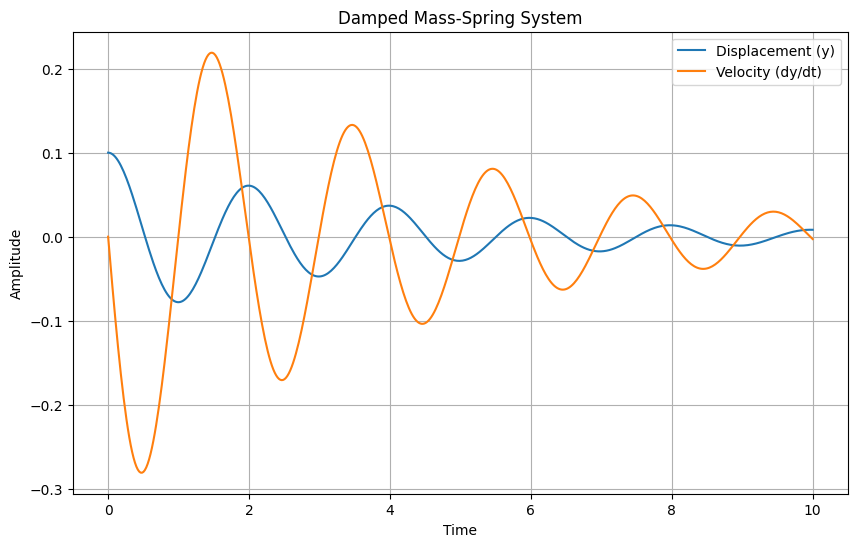

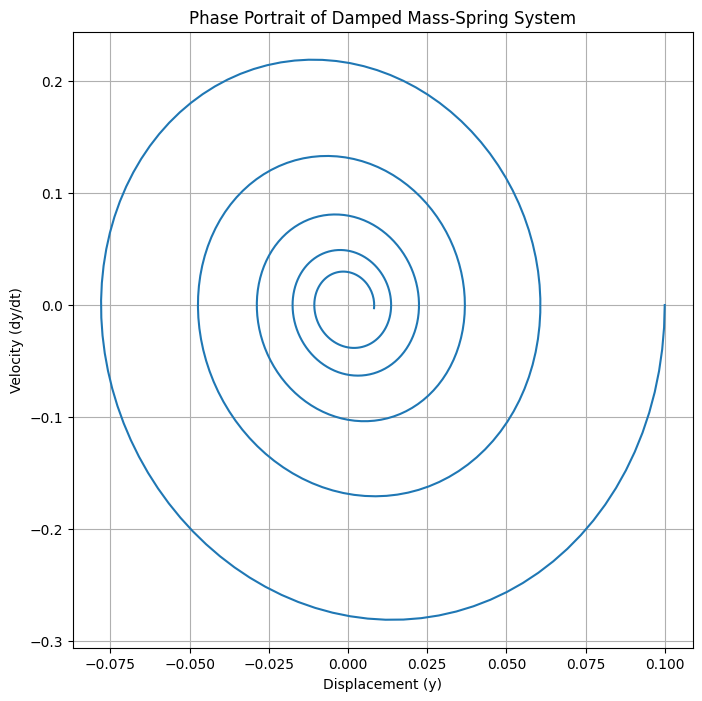

In [23]:
# 1. Define the derivative function for a coupled system
def damped_spring_deriv(y_vec, t, k, m, b):
    # y_vec[0] is displacement y
    # y_vec[1] is velocity dy/dt
    dy0_dt = y_vec[1]
    dy1_dt = -(k/m) * y_vec[0] - (b/m) * y_vec[1]
    return [dy0_dt, dy1_dt]

# 2. Set up initial conditions (y and dy/dt) and time array
k_val = 10.0
m_val = 1.0
b_val = 0.5 # Damping coefficient

yinit_spring = [0.1, 0] # Initial displacement y=0.1, initial velocity dy/dt=0
t_spring = np.linspace(0.0, 10.0, 500) # Time range

# 3. Solve the ODE system
solution_spring = odeint(damped_spring_deriv, yinit_spring, t_spring, args=(k_val, m_val, b_val))

# `solution_spring` is a 2D array:
# solution_spring[:, 0] contains displacement (y)
# solution_spring[:, 1] contains velocity (dy/dt)

# 4. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(t_spring, solution_spring[:, 0], label='Displacement (y)')
plt.plot(t_spring, solution_spring[:, 1], label='Velocity (dy/dt)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Damped Mass-Spring System')
plt.legend()
plt.grid(True)
plt.show()

# Phase space plot (velocity vs displacement)
plt.figure(figsize=(8, 8))
plt.plot(solution_spring[:, 0], solution_spring[:, 1])
plt.xlabel('Displacement (y)')
plt.ylabel('Velocity (dy/dt)')
plt.title('Phase Portrait of Damped Mass-Spring System')
plt.grid(True)
plt.show()

### 4. Parameter Estimation with `scipy.optimize.curve_fit`

`curve_fit` is used to fit a user-defined function to data, estimating the unknown parameters of the function. This is particularly useful when you have experimental data and a theoretical model (like an ODE solution) that depends on certain physical parameters.

**Key Requirements for `curve_fit`:**
*   **`func(x_data, param1, param2, ...)`**: The fitting function *must* take the independent variable (`x_data`, often time) as its first argument, followed by the parameters you want to fit. This function should return the predicted `y` values.
*   **`popt, pcov = curve_fit(func, x_data, y_data, p0=initial_guess)`**:
    *   `x_data`, `y_data`: Your experimental data.
    *   `p0`: An optional (but highly recommended) initial guess for the parameters. A good `p0` helps `curve_fit` converge to the correct solution.
    *   `popt`: Array containing the optimal values for the parameters.
    *   `pcov`: The covariance matrix of the parameters. Diagonal elements give the variance of each parameter.

**Code Shortcut:**
To integrate `odeint` with `curve_fit`, your `func` for `curve_fit` will internally call `odeint`.



Optimized spring constant (k): 9.4499
Optimized damping parameter (b): 0.4411


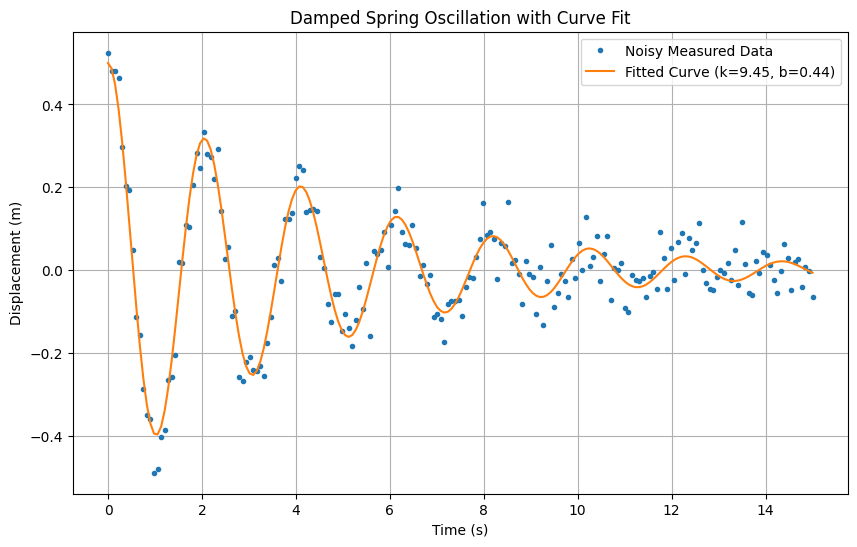

In [24]:
from scipy.optimize import curve_fit

# Simulate some noisy data for demonstration of curve_fit with an ODE
# (Using the damped spring model from above)

# True parameters for generating synthetic data
k_true = 9.5
m_fixed = 1.0
b_true = 0.45

yinit_data = [0.5, 0] # Initial displacement y=0.5, initial velocity dy/dt=0
t_data = np.linspace(0.0, 15.0, 200) # Time range

# Generate 'true' data without noise
true_solution = odeint(damped_spring_deriv, yinit_data, t_data, args=(k_true, m_fixed, b_true))
y_true = true_solution[:, 0]

# Add some random noise to simulate measurements
np.random.seed(42) # for reproducibility
y_noisy_data = y_true + 0.05 * np.random.randn(len(t_data))

# 1. Define the model function for curve_fit
# This function takes time (t) and the parameters to fit (k, b) as arguments.
# It internally uses odeint to solve the ODE with these parameters.
def damped_spring_model_for_fit(t_points, k_fit, b_fit):
    # Fixed parameters inside the model function
    m_const = 1.0
    y0_const = [0.5, 0] # Initial conditions fixed as per experiment

    # Solve the ODE for the given k_fit and b_fit
    sol = odeint(damped_spring_deriv, y0_const, t_points, args=(k_fit, m_const, b_fit))
    return sol[:, 0] # Return only the displacement (y) for fitting

# 2. Initial guess for the parameters (k, b)
guess_params = [10.0, 0.5]

# 3. Perform the curve fitting
popt, pcov = curve_fit(damped_spring_model_for_fit, t_data, y_noisy_data, p0=guess_params)

k_optimized, b_optimized = popt

print(f"Optimized spring constant (k): {k_optimized:.4f}")
print(f"Optimized damping parameter (b): {b_optimized:.4f}")

# 4. Plotting the results
y_fitted = damped_spring_model_for_fit(t_data, k_optimized, b_optimized)

plt.figure(figsize=(10, 6))
plt.plot(t_data, y_noisy_data, '.', label='Noisy Measured Data')
plt.plot(t_data, y_fitted, '-', label=f'Fitted Curve (k={k_optimized:.2f}, b={b_optimized:.2f})')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Damped Spring Oscillation with Curve Fit')
plt.legend()
plt.grid(True)
plt.show()

### 5. Non-Linear Oscillators: The Van der Pol Oscillator

The Van der Pol oscillator is an example of a non-linear oscillator that can exhibit complex behaviors, including limit cycles and chaotic dynamics. The exercise demonstrated how to solve such non-linear ODEs by converting them into coupled first-order equations, similar to the damped spring.

**Original ODE:** $$\frac{d^2y}{dt^2} - \mu(1 - y^2) \frac{dy}{dt} + y - A \sin(\omega t) = 0$$

**Transformed to First-Order System:**
1.  Let $y[0] = y$
2.  Let $y[1] = \frac{dy}{dt}$
3.  Then, $\frac{dy[0]}{dt} = y[1]$
4.  And $\frac{dy[1]}{dt} = \mu(1 - y[0]^2) y[1] - y[0] + A \sin(\omega t)$

**Key Plotting Technique: Phase Space Plots**
A phase space plot (or phase portrait) plots the velocity ($\frac{dy}{dt}$) against the displacement ($y$). This type of plot is invaluable for understanding the qualitative behavior of oscillatory systems, especially non-linear ones, as it reveals limit cycles, equilibria, and chaotic attractors.



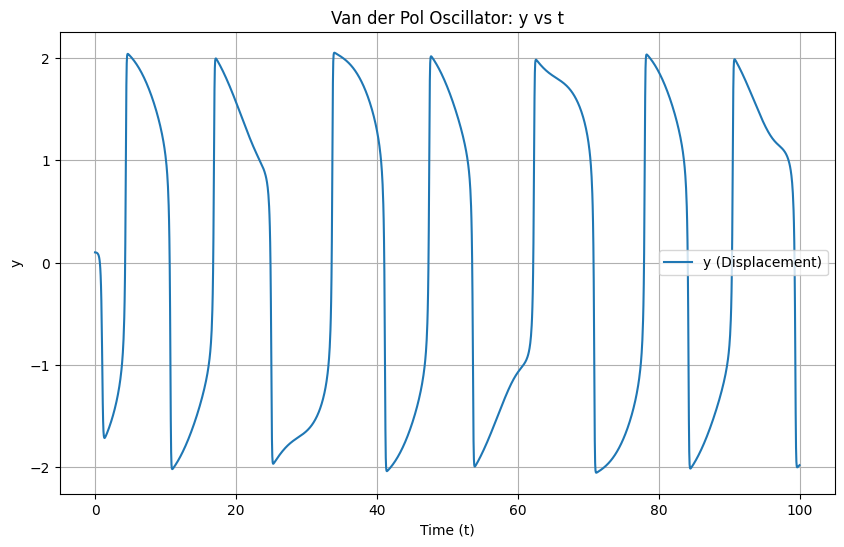

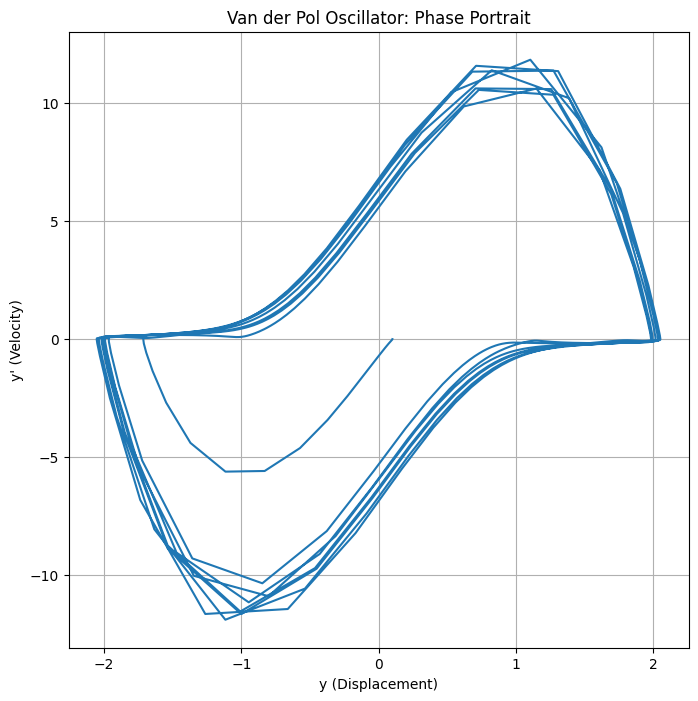

In [25]:
# 1. Define the derivative function for the Van der Pol oscillator
def van_der_pol_deriv_full(y_vec, t, mu, A, omega):
    # y_vec[0] is y (displacement)
    # y_vec[1] is dy/dt (velocity)
    dy0_dt = y_vec[1]
    dy1_dt = mu * (1 - y_vec[0]**2) * y_vec[1] - y_vec[0] + A * np.sin(omega * t)
    return [dy0_dt, dy1_dt]

# 2. Set up parameters, initial conditions, and time array
mu_vdP = 8.0
A_vdP = 1.0
omega_vdP = 0.6

yinit_vdP = [0.1, 0] # Initial displacement y=0.1, initial velocity dy/dt=0
t_vdP_long = np.linspace(0, 100, 2000) # Longer time range for non-linear behavior

# 3. Solve the ODE system
solution_vdP = odeint(van_der_pol_deriv_full, yinit_vdP, t_vdP_long, args=(mu_vdP, A_vdP, omega_vdP))

# 4. Plotting y vs t
plt.figure(figsize=(10, 6))
plt.plot(t_vdP_long, solution_vdP[:, 0], label='y (Displacement)')
plt.xlabel('Time (t)')
plt.ylabel('y')
plt.title('Van der Pol Oscillator: y vs t')
plt.legend()
plt.grid(True)
plt.show()

# 5. Plotting phase space (y' vs y)
plt.figure(figsize=(8, 8))
plt.plot(solution_vdP[:, 0], solution_vdP[:, 1])
plt.xlabel('y (Displacement)')
plt.ylabel("y' (Velocity)")
plt.title('Van der Pol Oscillator: Phase Portrait')
plt.grid(True)
plt.show()

### Summary of Key Functions and Concepts for Exam

*   **`numpy` (as `np`)**: Essential for numerical operations, arrays (`np.linspace`, `np.zeros_like`), and mathematical functions (`np.exp`, `np.sin`).
*   **`matplotlib.pyplot` (as `plt`)**: Crucial for plotting. Remember `plt.plot()`, `plt.xlabel()`, `plt.ylabel()`, `plt.title()`, `plt.legend()`, `plt.grid()`, `plt.show()`.
*   **`scipy.integrate.odeint`**: The core function for solving ODEs.
    *   Understand its arguments: `func`, `y0`, `t`, `args`.
    *   Know how to define `func` for single first-order ODEs and for systems of coupled first-order ODEs.
    *   Remember to handle initial conditions `y0` as a list/array for coupled systems.
*   **`scipy.optimize.curve_fit`**: For fitting models to data and estimating parameters.
    *   Understand the signature of the function you pass to `curve_fit`.
    *   Be able to provide an initial guess (`p0`).
    *   Interpret `popt` (optimal parameters).
*   **Transforming Higher-Order ODEs**: Convert any $n$-th order ODE into $n$ coupled first-order ODEs by introducing intermediate variables for derivatives.
*   **Phase Space Plots**: A powerful visualization tool for understanding the dynamics of oscillatory systems ($y'$ vs $y$).

Good luck with your exam!